# GWR mapping of convergence coefficients

In [ ]:
# Adding necessary libraries to Google Colab environment

# Installing the 'contextily' library for adding basemaps to plots.
# This library is useful for adding contextual geographical layers,
# such as maps, to visualizations. The '-q' flag is used to suppress
# unnecessary output during installation.
!pip install contextily -q

# Installing the 'splot' library for spatial data visualization.
# 'splot' works with PySAL to visualize spatial data, including spatial
# autocorrelation and cluster analysis. The '-q' flag is used to keep
# the output concise.
!pip install splot -q

# Installing additional libraries for spatial analysis and visualization.
# 'mapclassify' provides classification schemes for choropleth mapping,
# which can be useful for grouping spatial data into classes. This helps
# to visualize variations across different spatial regions more effectively.
!pip install mapclassify -q  # Library for choropleth mapping

# Installing the 'mgwr' library for performing geographically weighted
# regression (GWR). GWR is useful for understanding spatially varying
# relationships between variables by estimating local regression models.
# The '-q' flag is used to reduce verbosity during the installation process.
!pip install mgwr -q

In [ ]:
# Load libraries

# Library for plotting graphs and visualizations
import matplotlib.pyplot as plt

# Library for handling geospatial data
import geopandas as gpd

# Import GWR and MGWR for Geographically Weighted Regression
from mgwr.gwr import GWR, MGWR

# Import Sel_BW for selecting optimal bandwidth for GWR/MGWR
from mgwr.sel_bw import Sel_BW

# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

In [ ]:
##################################################################
# Application 3: Geographically Weighted Regression (GWR) Analysis
# URL: https://bit.ly/MGWRapp3
##################################################################

# 1. Load Data
# -------------------------------------
gdf = gpd.read_file(
    "https://github.com/quarcs-lab/data-quarcs/raw/refs/heads/master/"
    "indonesia514/gdfBeta.geojson"
)

# 2. Prepare Variables
# -------------------------------------
# - Dependent Variable: GDP growth ('g')
y = gdf["g"].values.reshape((-1, 1))  # Reshape to a column vector

# - Independent Variable: Log GDP per capita (2010)
X = gdf[["ln_gdppc2010"]].values  # Ensure X is a 2D array

# - Spatial Coordinates: X and Y positions
u = gdf["COORD_X"]  # X-coordinates
v = gdf["COORD_Y"]  # Y-coordinates
coords = list(zip(u, v))  # List of tuples representing each location

# 3. Bandwidth Selection for GWR
# -------------------------------------
# - Select the optimal bandwidth controlling the spatial influence
gwr_selector = Sel_BW(coords, y, X, spherical=True)
gwr_bw = gwr_selector.search()

# 4. Fit the GWR Model
# -------------------------------------
# - Fit the model using the optimal bandwidth and spatial data
gwr_results = GWR(coords, y, X, gwr_bw).fit()

# 5. Display Results
# -------------------------------------
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 514
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                             41.453
Log-likelihood:                                                     -82.296
AIC:                                                                168.592
AICc:                                                               170.639
BIC:                                                              -3154.565
R2:                                                                   0.214
Adj. R2:                                                              0.212

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

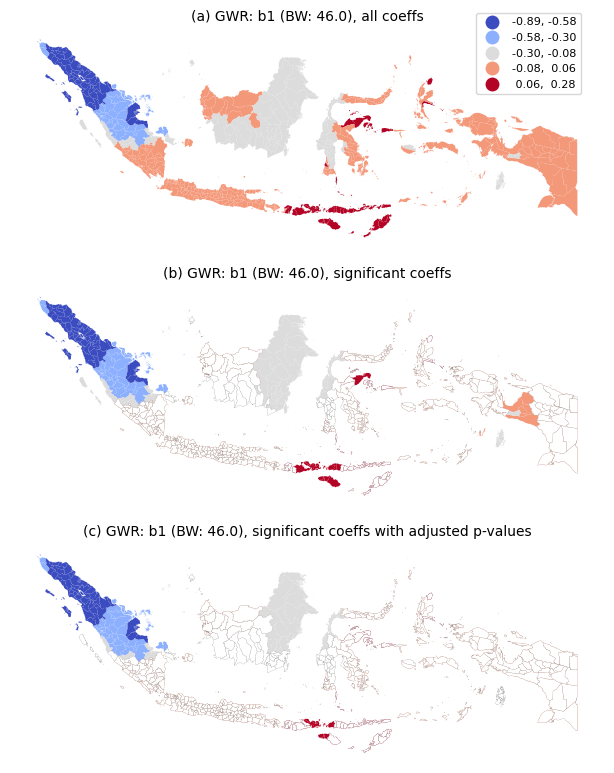

In [ ]:
##################################################################
# Application 4: GWR Coefficient Mapping and Filtering
# URL: https://bit.ly/MGWRapp4
##################################################################

# 1. Add GWR Coefficients to the GeoDataFrame
# -------------------------------------
gdf["gwr_intercept"] = gwr_results.params[:, 0]
gdf["gwr_b1"] = gwr_results.params[:, 1]

# 2. Filter t-values for Significance
# -------------------------------------
# - Standard significance level (alpha = 0.05)
gwr_filtered_t = gwr_results.filter_tvals(alpha=0.05)

# - Adjusted significance level (corrected for multiple testing)
gwr_filtered_tc = gwr_results.filter_tvals()

# 3. Plot the b1 Coefficient
# -------------------------------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8))

# (a) Map of all coefficients
gdf.plot(
    column="gwr_b1",
    cmap="coolwarm",
    linewidth=0.01,
    scheme="FisherJenks",
    k=5,
    legend=True,
    legend_kwds={"bbox_to_anchor": (0.97, 1.10), "fontsize": 8},
    ax=axes[0]
)

# (b) Map highlighting statistically significant coefficients (alpha = 0.05)
gdf.plot(
    column="gwr_b1",
    cmap="coolwarm",
    linewidth=0.05,
    scheme="FisherJenks",
    k=5,
    legend=False,
    ax=axes[1]
)
gdf[gwr_filtered_t[:, 1] == 0].plot(
    color="white",
    linewidth=0.05,
    edgecolor="black",
    ax=axes[1]
)

# (c) Map highlighting statistically significant coefficients with adjusted p-values
gdf.plot(
    column="gwr_b1",
    cmap="coolwarm",
    linewidth=0.05,
    scheme="FisherJenks",
    k=5,
    legend=False,
    ax=axes[2]
)
gdf[gwr_filtered_tc[:, 1] == 0].plot(
    color="white",
    linewidth=0.05,
    edgecolor="black",
    ax=axes[2]
)

# 4. Customize Layout and Appearance
# -------------------------------------
plt.tight_layout()

# Remove axes for a cleaner presentation
for ax in axes:
    ax.axis("off")

# Set subplot titles with consistent styling
axes[0].set_title(
    f"(a) GWR: b1 (BW: {gwr_bw}), all coeffs", fontsize=10
)
axes[1].set_title(
    f"(b) GWR: b1 (BW: {gwr_bw}), significant coeffs", fontsize=10
)
axes[2].set_title(
    f"(c) GWR: b1 (BW: {gwr_bw}), significant coeffs with adjusted p-values",
    fontsize=10
)

# 5. Save and Display the Figure
# -------------------------------------
plt.savefig("gwr_b1.png", dpi=100, bbox_inches="tight")
plt.show()
